# Problem Set #3

Mariajosé Argote, Felipe Manzi, and Xiaoyan Wang

## Question 1 

### part(a)



The main idea here is to see how $\varepsilon$ changes the strength of community structure in the planted partition model. It matters because $\varepsilon$ controls how different the within-group and across-group connection probabilities are: when that gap is larger, the two communities should be easier to see.

For $c=2$, we use

$$
p=\frac{d+\varepsilon}{n}, \qquad q=\frac{d-\varepsilon}{n},
$$

where $p$ is the within-group probability and $q$ is the across-group probability. So increasing $\varepsilon$ makes within-group links more likely and across-group links less likely, while keeping the average degree around $d$.

The pattern in the three graphs is what we would expect. When $\varepsilon=0$, we have $p=q$, so there is basically no visible community structure. When $\varepsilon=4$, the separation becomes noticeable but still moderate. When $\varepsilon=8$, the difference is much stronger, so the two groups look much more clearly separated.

So the main takeaway is that larger $\varepsilon$ means stronger community structure: the graph goes from mostly mixed at $\varepsilon=0$ to clearly clustered at $\varepsilon=8$.

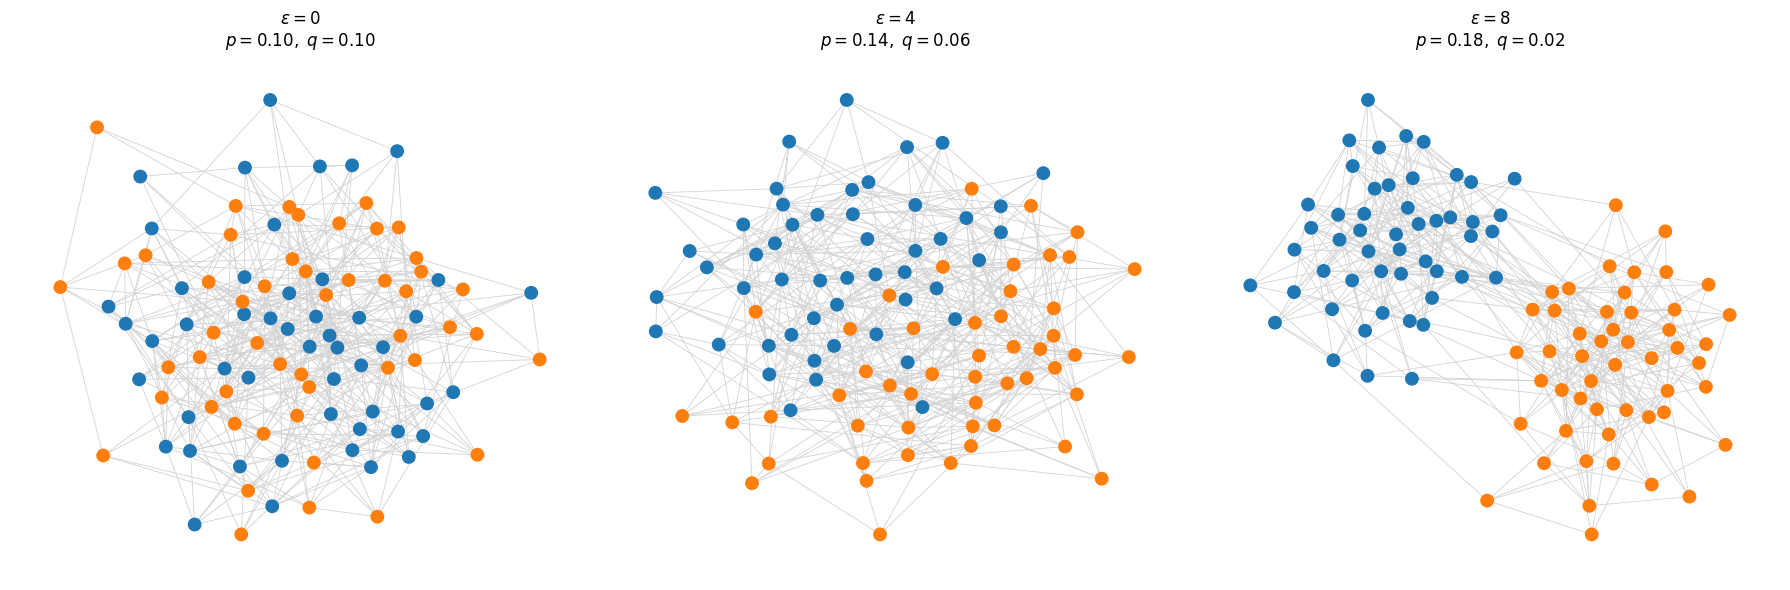

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def planted_partition_graph(n, c, d, eps, seed=None):
    rng = np.random.default_rng(seed)
    sizes = [n // c] * c
    for i in range(n % c):
        sizes[i] += 1

    p = (d + eps) / n
    q = (d - eps) / n

    G = nx.Graph()
    group_labels = {}

    start = 0
    groups = []
    for r, size in enumerate(sizes):
        nodes = list(range(start, start + size))
        groups.append(nodes)
        for node in nodes:
            G.add_node(node)
            group_labels[node] = r
        start += size

    for i in range(n):
        for j in range(i + 1, n):
            if group_labels[i] == group_labels[j]:
                if rng.random() < p:
                    G.add_edge(i, j)
            else:
                if rng.random() < q:
                    G.add_edge(i, j)

    return G, group_labels, p, q

# Parameters
n = 100
c = 2
d = 10
eps_values = [0, 4, 8]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, eps in zip(axes, eps_values):
    G, group_labels, p, q = planted_partition_graph(n=n, c=c, d=d, eps=eps, seed=42)
    
    # fixed layout for consistency
    pos = nx.spring_layout(G, seed=42)
    colors = ["tab:blue" if group_labels[node] == 0 else "tab:orange" for node in G.nodes()]
    
    nx.draw_networkx(
        G,
        pos=pos,
        ax=ax,
        node_color=colors,
        node_size=80,
        with_labels=False,
        edge_color="lightgray",
        width=0.6
    )
    
    ax.set_title(rf"$\varepsilon={eps}$" + f"\n" + rf"$p={p:.2f}, \ q={q:.2f}$")
    ax.axis("off")

plt.tight_layout()
plt.show()

When $\varepsilon=0$, we have $p=q$, so there is essentially no visible community structure and the graph looks fairly mixed. When $\varepsilon=4$, the two groups start to become more noticeable, although there are still many cross-group edges. When $\varepsilon=8$, the within-group connectivity is much stronger than the across-group connectivity, so the two communities appear much more clearly separated.

### part(b)

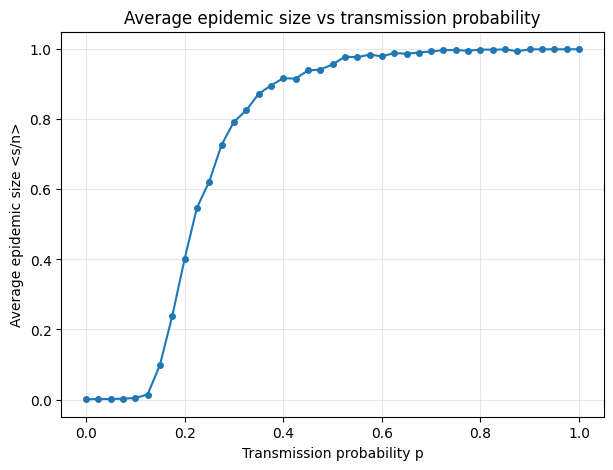

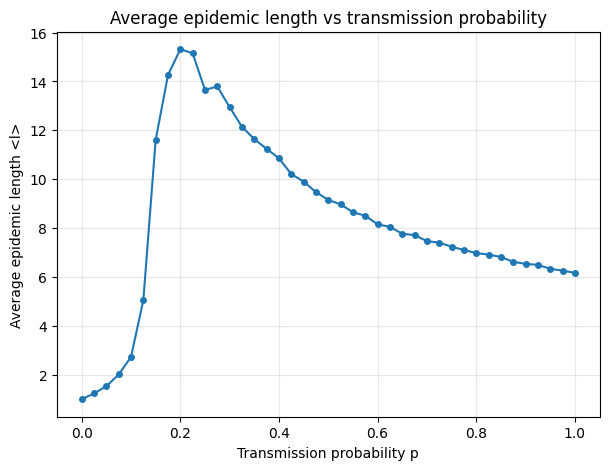

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# 1. Planted partition generator
# -------------------------------
def planted_partition_graph(n, c, d, eps, seed=None):
    rng = np.random.default_rng(seed)

    sizes = [n // c] * c
    for i in range(n % c):
        sizes[i] += 1

    p_in = (d + eps) / n
    p_out = (d - eps) / n

    G = nx.Graph()
    group_of = {}

    start = 0
    groups = []
    for r, size in enumerate(sizes):
        nodes = list(range(start, start + size))
        groups.append(nodes)
        for node in nodes:
            G.add_node(node)
            group_of[node] = r
        start += size

    for i in range(n):
        for j in range(i + 1, n):
            if group_of[i] == group_of[j]:
                if rng.random() < p_in:
                    G.add_edge(i, j)
            else:
                if rng.random() < p_out:
                    G.add_edge(i, j)

    return G


# ---------------------------------------
# 2. Independent Cascade / simple SI model
# ---------------------------------------
def simulate_ic(G, trans_prob, rng):
    nodes = list(G.nodes())
    n = len(nodes)

    # t = 1: choose one seed uniformly at random
    seed_node = rng.choice(nodes)

    infected = set([seed_node])
    newly_infected = set([seed_node])
    infection_time = {seed_node: 1}

    t = 1

    while newly_infected:
        next_new = set()

        for u in newly_infected:
            for v in G.neighbors(u):
                if v not in infected:
                    # each infected node gets one chance to infect each susceptible neighbor
                    if rng.random() < trans_prob:
                        next_new.add(v)

        if not next_new:
            break

        t += 1
        for v in next_new:
            infected.add(v)
            infection_time[v] = t

        newly_infected = next_new

    epidemic_size = len(infected) / n
    epidemic_length = max(infection_time.values()) if infection_time else 0

    return epidemic_size, epidemic_length


# ---------------------------------------
# 3. Run simulations over p in [0,1]
# ---------------------------------------
n = 1000
c = 2
d = 8
eps = 0

# make p vary slowly enough for smooth curves
p_values = np.linspace(0, 1, 41)

# averages over multiple draws of graph + cascade
num_graphs = 20
num_cascades_per_graph = 20

avg_sizes = []
avg_lengths = []

master_rng = np.random.default_rng(42)

for trans_prob in p_values:
    sizes = []
    lengths = []

    for g in range(num_graphs):
        graph_seed = master_rng.integers(1_000_000_000)
        G = planted_partition_graph(n=n, c=c, d=d, eps=eps, seed=graph_seed)

        for _ in range(num_cascades_per_graph):
            size, length = simulate_ic(G, trans_prob, master_rng)
            sizes.append(size)
            lengths.append(length)

    avg_sizes.append(np.mean(sizes))
    avg_lengths.append(np.mean(lengths))


# ---------------------------------------
# 4. Plot average epidemic size
# ---------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(p_values, avg_sizes, marker='o', linewidth=1.5, markersize=4)
plt.xlabel("Transmission probability p")
plt.ylabel("Average epidemic size <s/n>")
plt.title("Average epidemic size vs transmission probability")
plt.grid(True, alpha=0.3)
plt.show()


# ---------------------------------------
# 5. Plot average epidemic length
# ---------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(p_values, avg_lengths, marker='o', linewidth=1.5, markersize=4)
plt.xlabel("Transmission probability p")
plt.ylabel("Average epidemic length <l>")
plt.title("Average epidemic length vs transmission probability")
plt.grid(True, alpha=0.3)
plt.show()



The main idea here is to see how the transmission probability $p$ affects the epidemic once we remove community structure by setting $\varepsilon=0$. Since the network is basically homogeneous in this case, the main question is just whether infection can spread often enough to sustain a large cascade.

From the figures, the behavior is pretty clear. For small $p$, the average epidemic size $\langle s/n \rangle$ is close to $0$, so outbreaks usually stay very small. But around $p \approx 0.2$, the curve rises very quickly, which suggests a phase transition. After that, the average epidemic size gets close to $1$, meaning the epidemic usually reaches almost the whole network.

The average epidemic length $\langle l \rangle$ peaks around the same region. This also makes intuitive sense: near the threshold, the infection spreads farthest before stopping, so the process lasts the longest. Once $p$ becomes large, the epidemic still reaches many nodes, but it does so faster, so the total length starts to decrease.

Overall, the results are very close to what I would expect. There seems to be a critical value of $p$ around $0.2$, where the behavior changes from small outbreaks to large cascades.

### part(c)

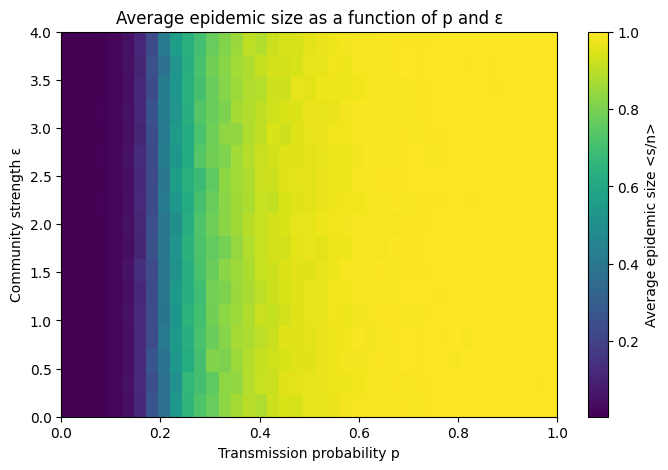

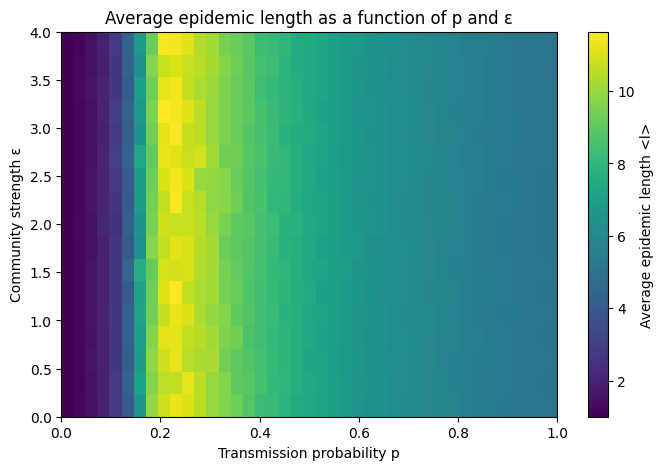

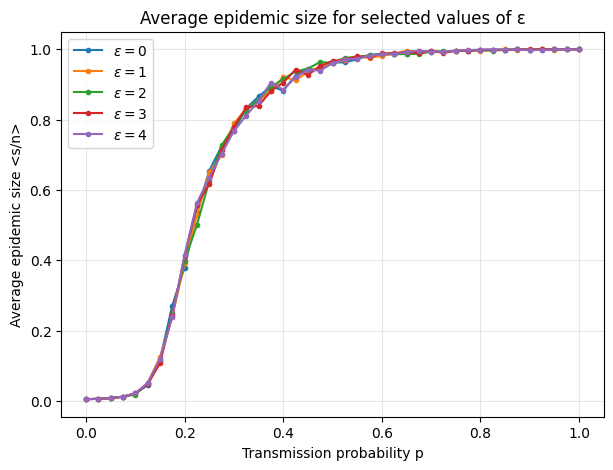

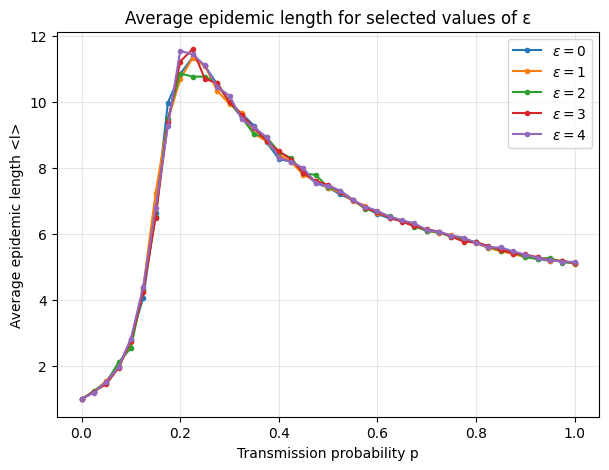

In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Planted partition graph generator
# -----------------------------------
def planted_partition_graph(n, c, d, eps, seed=None):
    rng = np.random.default_rng(seed)

    sizes = [n // c] * c
    for i in range(n % c):
        sizes[i] += 1

    p_in = (d + eps) / n
    p_out = (d - eps) / n

    G = nx.Graph()
    group_of = {}

    start = 0
    for r, size in enumerate(sizes):
        nodes = list(range(start, start + size))
        for node in nodes:
            G.add_node(node)
            group_of[node] = r
        start += size

    for i in range(n):
        for j in range(i + 1, n):
            if group_of[i] == group_of[j]:
                if rng.random() < p_in:
                    G.add_edge(i, j)
            else:
                if rng.random() < p_out:
                    G.add_edge(i, j)

    return G


# -----------------------------------
# 2. Independent Cascade / simple SI
# -----------------------------------
def simulate_ic(G, trans_prob, rng):
    nodes = list(G.nodes())
    n = len(nodes)

    seed_node = rng.choice(nodes)   # infect one node at t = 1

    infected = {seed_node}
    newly_infected = {seed_node}
    infection_time = {seed_node: 1}

    t = 1

    while newly_infected:
        next_new = set()

        for u in newly_infected:
            for v in G.neighbors(u):
                if v not in infected:
                    if rng.random() < trans_prob:
                        next_new.add(v)

        if not next_new:
            break

        t += 1
        for v in next_new:
            infected.add(v)
            infection_time[v] = t

        newly_infected = next_new

    epidemic_size = len(infected) / n
    epidemic_length = max(infection_time.values()) if infection_time else 0

    return epidemic_size, epidemic_length


# -----------------------------------
# 3. Parameter sweep
# -----------------------------------
n = 200
c = 2
d = 8

# transmission probability grid
p_values = np.linspace(0, 1, 41)

# community strength grid: epsilon in [0, 2c] = [0, 4]
eps_values = np.linspace(0, 2*c, 17)

num_graphs = 30
num_cascades_per_graph = 20

avg_size = np.zeros((len(eps_values), len(p_values)))
avg_length = np.zeros((len(eps_values), len(p_values)))

master_rng = np.random.default_rng(42)

for i, eps in enumerate(eps_values):
    for j, trans_prob in enumerate(p_values):
        sizes = []
        lengths = []

        for _ in range(num_graphs):
            graph_seed = master_rng.integers(1_000_000_000)
            G = planted_partition_graph(n=n, c=c, d=d, eps=eps, seed=graph_seed)

            for _ in range(num_cascades_per_graph):
                s, l = simulate_ic(G, trans_prob, master_rng)
                sizes.append(s)
                lengths.append(l)

        avg_size[i, j] = np.mean(sizes)
        avg_length[i, j] = np.mean(lengths)


# -----------------------------------
# 4. Heatmap: average epidemic size
# -----------------------------------
plt.figure(figsize=(8, 5))
im = plt.imshow(
    avg_size,
    aspect='auto',
    origin='lower',
    extent=[p_values.min(), p_values.max(), eps_values.min(), eps_values.max()]
)
plt.colorbar(im, label='Average epidemic size <s/n>')
plt.xlabel('Transmission probability p')
plt.ylabel('Community strength ε')
plt.title('Average epidemic size as a function of p and ε')
plt.show()


# -----------------------------------
# 5. Heatmap: average epidemic length
# -----------------------------------
plt.figure(figsize=(8, 5))
im = plt.imshow(
    avg_length,
    aspect='auto',
    origin='lower',
    extent=[p_values.min(), p_values.max(), eps_values.min(), eps_values.max()]
)
plt.colorbar(im, label='Average epidemic length <l>')
plt.xlabel('Transmission probability p')
plt.ylabel('Community strength ε')
plt.title('Average epidemic length as a function of p and ε')
plt.show()


# -----------------------------------
# 6. Optional line plots for clarity
# -----------------------------------
selected_eps = [0, 1, 2, 3, 4]

plt.figure(figsize=(7, 5))
for eps in selected_eps:
    idx = np.argmin(np.abs(eps_values - eps))
    plt.plot(p_values, avg_size[idx], marker='o', markersize=3, label=rf'$\varepsilon={eps}$')
plt.xlabel('Transmission probability p')
plt.ylabel('Average epidemic size <s/n>')
plt.title('Average epidemic size for selected values of ε')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
for eps in selected_eps:
    idx = np.argmin(np.abs(eps_values - eps))
    plt.plot(p_values, avg_length[idx], marker='o', markersize=3, label=rf'$\varepsilon={eps}$')
plt.xlabel('Transmission probability p')
plt.ylabel('Average epidemic length <l>')
plt.title('Average epidemic length for selected values of ε')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



The main idea here is to see whether stronger community structure changes how far or how long the epidemic spreads. In the planted partition model,
$$
p_{\text{in}}=\frac{d+\varepsilon}{n}, \qquad p_{\text{out}}=\frac{d-\varepsilon}{n},
$$
so larger $\varepsilon$ means stronger within-group connections and weaker across-group connections.

From the figures, though, the effect of $\varepsilon$ is very small. The epidemic size curves for different values of $\varepsilon$ are almost identical, and the epidemic length curves are also very close. The main change still comes from $p$: there is a clear transition around $p \approx 0.2$, where outbreaks go from small to large.

So compared with part (b), the overall shape is basically the same. In this case, stronger community structure does not seem to matter much. My interpretation is that the two groups are still connected enough that once transmission becomes likely, the infection can spread through the whole network almost as easily as before.

# Question 2

Part (a)

In [15]:
import os
import math
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from itertools import combinations
from collections import defaultdict

In [14]:
random.seed(1000)
np.random.seed(1000)
 
# Load dolphins network
G = nx.read_gml('dolphins.gml')
print(f"Dolphins network: n={G.number_of_nodes()}, m={G.number_of_edges()}")
print(f"Average degree: {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"Total seed pairs to evaluate: {G.number_of_nodes()*(G.number_of_nodes()-1)//2}")
 
# Parameters
gamma_values = [1, 2]
periods = 4
model_iterations = 60

Dolphins network: n=62, m=159
Average degree: 5.13
Total seed pairs to evaluate: 1891


We truncate because a negative threshold would mean a node adopts with zero adopted neighbours, immediate adoption. That defeats the purpose of a social influence model.
    

In [18]:
def generate_tau(gamma):
    """
    Draw a single adoption threshold from N(gamma, 0.5),
    truncated to be strictly positive.
    
    """
    while True:
        t = random.gauss(gamma, 0.5)
        if t > 0:
            return t
 
 
def threshold_diffusion(G, seeds, gamma, periods=4):
    """
    Run one simulation of threshold diffusion.
    
    MECHANICS:
    1. Draw ONE threshold per node (random, done once per sim)
    2. Seed nodes start as adopted at t=0
    3. Each period: for every non-adopted node, COUNT how many
       of its neighbours are adopted. If count >= threshold, adopt.
    4. Updates are simultaneous (all nodes check at once, then flip)
    5. After 4 periods, return fraction adopted.
    
    This is NOT independent cascade. There is no per-edge coin flip.
    The threshold is a COUNT of adopted neighbours needed, not a 
    probability.
    """
    # Step 1: Draw thresholds for all nodes (once per simulation)
    tau = {v: generate_tau(gamma) for v in G.nodes()}
 
    # Step 2: Initialize seeds as adopted
    adopted = set(seeds)
 
    # Step 3: Run 4 periods
    for period in range(periods):
        new_adopters = set()
        for v in G.nodes():
            if v in adopted:
                continue
            # COUNT adopted neighbours — this is the key mechanic
            adopted_nbrs = sum(1 for u in G.neighbors(v) if u in adopted)
            # Threshold check: adopt if count >= tau
            if adopted_nbrs >= tau[v]:
                new_adopters.add(v)
        # Simultaneous update
        adopted |= new_adopters
 
    # Return adoption rate
    return len(adopted) / G.number_of_nodes()
 
 
def evaluate_pair(G, seeds, gamma, n_sims=60):
    """
    Run n_sims simulations for a given seed pair and return
    the average adoption rate. Each sim draws fresh thresholds.
    """
    total = sum(
        threshold_diffusion(G, seeds, gamma, periods)
        for _ in range(n_sims)
    )
    return total / n_sims
 

In [19]:
# Part (a) - evaluate all pairs of seeds for both gamma values
 
all_pairs = list(combinations(G.nodes(), 2))
results = {}
 
for gamma in gamma_values:
    print(f"Lambda = {gamma}")
    print(f"  Evaluating {len(all_pairs)} pairs × {model_iterations} simulations...")
 
    scores = {}
    for idx, pair in enumerate(all_pairs):
        scores[pair] = evaluate_pair(G, pair, gamma, model_iterations)
        # Progress update every 200 pairs
        if (idx + 1) % 200 == 0:
            print(f"  ...{idx+1}/{len(all_pairs)} pairs done")
 
    results[gamma] = scores
    print(f"  Scores range: [{min(scores.values()):.3f}, {max(scores.values()):.3f}]")

Lambda = 1
  Evaluating 1891 pairs × 60 simulations...
  ...200/1891 pairs done
  ...400/1891 pairs done
  ...600/1891 pairs done
  ...800/1891 pairs done
  ...1000/1891 pairs done
  ...1200/1891 pairs done
  ...1400/1891 pairs done
  ...1600/1891 pairs done
  ...1800/1891 pairs done
  Done. Scores range: [0.199, 0.906]
Lambda = 2
  Evaluating 1891 pairs × 60 simulations...
  ...200/1891 pairs done
  ...400/1891 pairs done
  ...600/1891 pairs done
  ...800/1891 pairs done
  ...1000/1891 pairs done
  ...1200/1891 pairs done
  ...1400/1891 pairs done
  ...1600/1891 pairs done
  ...1800/1891 pairs done
  Done. Scores range: [0.032, 0.322]


In [21]:
# Part (b) - find best pairs and plot

print("Part (b): Optimal seed pairs and their adoption rates")
optimal_pairs = {}
for gamma in gamma_values:
    scores = results[gamma]
    best_pair = max(scores, key=scores.get)
    best_rate = scores[best_pair]
    optimal_pairs[gamma] = (best_pair, best_rate)
 
    # Also show top 5 for context
    top5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
 
    print(f"\nLambda = {gamma}:")
    print(f"  OPTIMAL PAIR: {best_pair}")
    print(f"  Average adoption rate: {best_rate:.4f}")
    print(f"  Degrees: {G.degree(best_pair[0])}, {G.degree(best_pair[1])}")


Part (b): Optimal seed pairs and their adoption rates

Lambda = 1:
  OPTIMAL PAIR: ('Gallatin', 'SN4')
  Average adoption rate: 0.9065
  Degrees: 8, 11

Lambda = 2:
  OPTIMAL PAIR: ('Grin', 'Scabs')
  Average adoption rate: 0.3223
  Degrees: 12, 10


## Question3

### part(a)



The key idea here is that each origin-destination pair has two possible routes: an outer route with cost $1+x$, or a route through the middle edge with cost $3x$. The only shared congestion comes from the middle edge, since both pairs can use it.

Let $a$ be the flow on the top outer road and $b$ the flow on the bottom outer road. Then the middle-edge flow is
$$
m = 2-a-b.
$$
So the total social cost is
$$
C(a,b)=a(1+a)+b(1+b)+3(2-a-b)^2.
$$

By symmetry, the optimum has $a=b$, and solving the first-order conditions gives
$$
a=b=\frac{11}{14}, \qquad m=\frac{3}{7}.
$$
The total optimal cost is
$$
C^*=\frac{329}{98}\approx 3.36.
$$

So the social optimum uses mostly the two outer roads, but still sends some traffic through the middle. The reason is that the middle road is useful, but too much shared flow there becomes inefficient.

### part(b)



The main idea here is that at equilibrium, users minimize their own travel cost, not the total cost. So compared with the social optimum, equilibrium can put too much traffic on the shared middle edge.

For the top pair, the two route costs are
$$
1+a \quad \text{and} \quad 3m,
$$
and similarly for the bottom pair. At equilibrium, any route used with positive flow must have the same cost. By symmetry, let
$$
a=b=t, \qquad m=2-2t.
$$
Then
$$
1+t=3(2-2t),
$$
which gives
$$
t=\frac{5}{7}.
$$
So the equilibrium routing is
$$
a=b=\frac{5}{7}, \qquad m=\frac{4}{7}.
$$
The total equilibrium cost is
$$
C^{eq}=\frac{24}{7}\approx 3.43.
$$

The welfare loss is
$$
C^{eq}-C^*=\frac{24}{7}-\frac{329}{98}=\frac{1}{14}\approx 0.071.
$$

So the equilibrium overuses the middle road a bit, because each user does not take into account the congestion they create for others.

### part(c)



The key idea here is to add a toll so that the social optimum becomes an equilibrium. Since the middle road is overused, we want to make it slightly less attractive.

At the social optimum,
$$
a=b=\frac{11}{14}, \qquad m=\frac{3}{7}.
$$
The outer-route cost is
$$
1+\frac{11}{14}=\frac{25}{14},
$$
while the middle-route cost is
$$
3\cdot\frac{3}{7}=\frac{9}{7}=\frac{18}{14}.
$$
So the middle route is cheaper by
$$
\frac{25}{14}-\frac{18}{14}=\frac{1}{2}.
$$

So one simple solution is to put a constant toll
$$
\tau=\frac{1}{2}
$$
on the middle edge. Then at the social optimum, the perceived middle-route cost becomes
$$
3m+\tau=\frac{9}{7}+\frac{1}{2}=\frac{25}{14},
$$
which matches the outer-route cost.

So a toll of $\frac{1}{2}$ on the middle edge implements the social optimum as an equilibrium.